# Notebook 10 — Sensitivity Analysis

**Purpose**: How robust is our model to changes in assumptions and data availability?

This notebook tests three questions thesis examiners often ask:

1. **Cost sensitivity** — If the cost of a false alarm changes, how does the optimal threshold shift?
2. **Data hunger** — How much training data does the model actually need? At what point does performance plateau?
3. **Policy trade-offs** — What does each threshold policy sacrifice to achieve its goal?

All analysis uses the trained LightGBM champion model and pre-computed artifacts. No retraining of the champion occurs here — we retrain smaller models only for the data-hunger experiment.

In [1]:
# --- Setup ---
from pathlib import Path

from src.eval.notebook_utils import (
    setup_plotting,
    load_sensitivity_context,
    cost_sensitivity_sweep,
    plot_cost_sensitivity,
    dataset_size_sensitivity,
    plot_dataset_size_sensitivity,
    threshold_policy_comparison,
    plot_threshold_policy_comparison,
    save_thesis_figure,
)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

style = setup_plotting()
FIG_DIR = Path("../reports/figures/thesis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK, loading context...")
ctx = load_sensitivity_context()
print(f"Loaded: {ctx['metrics']['selected_model_family']} champion")
print(f"Train: {len(ctx['X_train']):,} rows | Val: {len(ctx['X_val']):,} rows | Test: {len(ctx['X_test']):,} rows")

Imports OK, loading context...


Loaded: lightgbm champion
Train: 95,367 rows | Val: 11,920 rows | Test: 11,922 rows


---
## 10.1 Cost Sensitivity — What if intervention costs change?

Our cost-sensitive threshold assumes each false positive costs **EUR 15** (the cost of contacting a guest who wasn't going to cancel). But this number depends on the hotel's operations:

- A budget hotel with automated emails might spend only EUR 1-5 per contact
- A luxury resort with personal phone calls might spend EUR 50-100

**Question**: How much does the optimal threshold move when we change this assumption?

In [2]:
# Sweep FP intervention costs from EUR 1 to EUR 100
cost_df = cost_sensitivity_sweep(
    ctx,
    fp_costs=[1.0, 5.0, 10.0, 15.0, 25.0, 50.0, 75.0, 100.0],
)

cost_df.style.format({
    "FP Cost": "EUR {:.0f}",
    "Optimal Threshold": "{:.2f}",
    "Total Cost": "EUR {:,.0f}",
    "FP Count": "{:,}",
    "FN Count": "{:,}",
}).set_caption("Table 10.1 — Cost-sensitive threshold at different FP intervention costs")

,FP Cost,Optimal Threshold,Total Cost,FP Count,FN Count
0,EUR 1,0.01,"EUR 5,580","4,645.0",3.0
1,EUR 5,0.02,"EUR 23,120","4,278.0",8.0
2,EUR 10,0.04,"EUR 43,571","3,724.0",29.0
3,EUR 15,0.04,"EUR 62,191","3,724.0",29.0
4,EUR 25,0.06,"EUR 98,117","3,313.0",51.0
5,EUR 50,0.12,"EUR 180,727","3,164.0",71.0
6,EUR 75,0.13,"EUR 259,400","3,102.0",80.0
7,EUR 100,0.19,"EUR 333,278","2,763.0",147.0


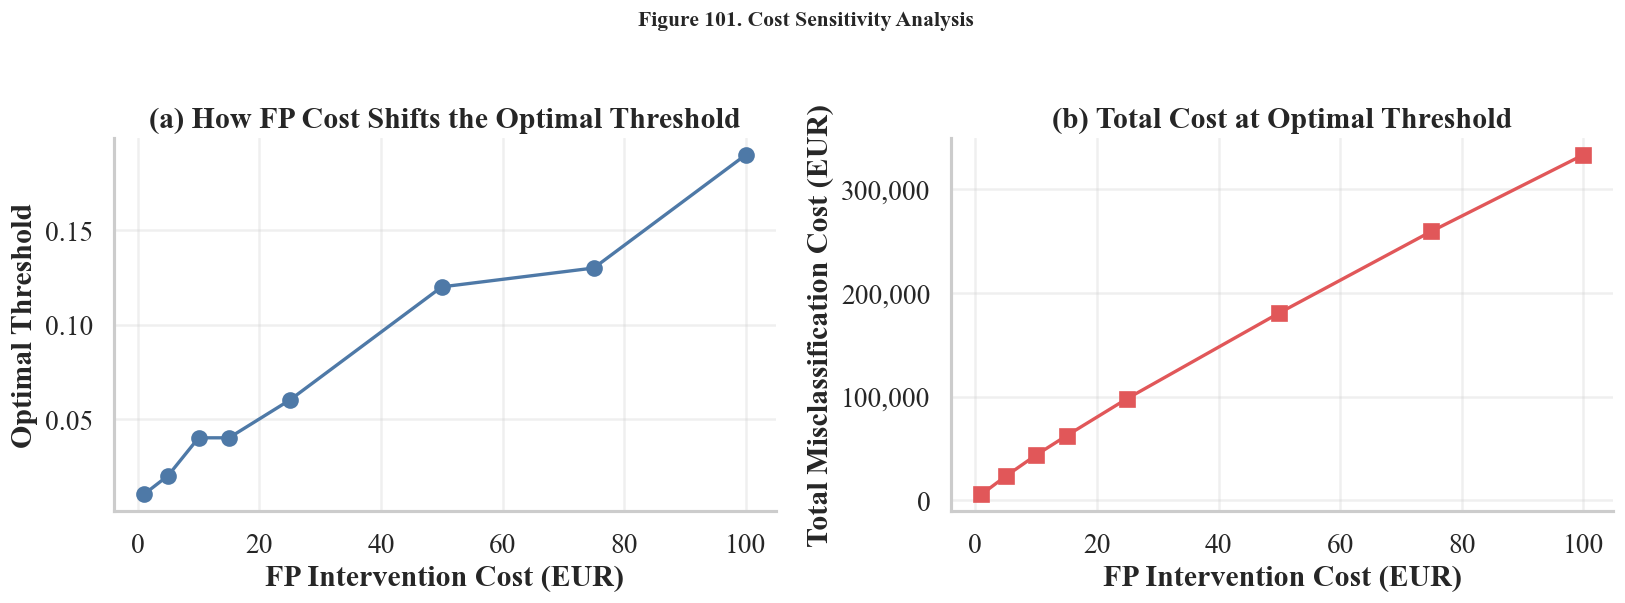

In [3]:
plot_cost_sensitivity(cost_df, FIG_DIR, fig_no=101)

**How to read this chart:**
- Panel (a) shows the optimal decision threshold at each FP cost level
- Panel (b) shows the total misclassification cost (false alarms + missed cancellations) at that optimal threshold

**Key Takeaway**: When false alarms are cheap (EUR 1-5), the model flags almost every booking (low threshold). As FP cost rises, the threshold increases — the model becomes more selective, only flagging high-confidence cancellations. This means hotels should calibrate the FP cost to their actual intervention process before deploying.

---
## 10.2 Data Hunger — How much training data does the model need?

We trained on ~95,000 bookings. But what if a hotel only has 10,000? Or 50,000?

This experiment trains fresh LightGBM models on progressively smaller random subsets of the training data (10% to 100%) and evaluates each on the same held-out validation set. Each subset size is repeated 3 times with different random seeds to measure variance.

**Question**: Where does the performance curve plateau? How small can the dataset get before accuracy drops significantly?

In [4]:
# Train on subsets: 10%, 20%, 30%, 50%, 70%, 100% of training data
# Each repeated 3x with different seeds
size_df = dataset_size_sensitivity(
    ctx,
    fractions=[0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
    n_repeats=3,
)

size_df.style.format({
    "Fraction": "{:.0%}",
    "Rows": "{:,}",
    "ROC-AUC Mean": "{:.4f}",
    "ROC-AUC Std": "{:.4f}",
    "PR-AUC Mean": "{:.4f}",
    "PR-AUC Std": "{:.4f}",
    "F1 Mean": "{:.4f}",
    "F1 Std": "{:.4f}",
}).set_caption("Table 10.2 — Model performance by training set size")

,Fraction,Rows,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,F1 Mean,F1 Std
0,10%,"9,536",0.9124,0.0013,0.8983,0.0021,0.7699,0.0078
1,20%,"19,073",0.9141,0.0005,0.8998,0.0009,0.7747,0.0053
2,30%,"28,610",0.9139,0.0007,0.8988,0.0010,0.7757,0.0039
3,50%,"47,683",0.9154,0.0009,0.9001,0.0009,0.7763,0.0036
4,70%,"66,756",0.9151,0.0009,0.8997,0.0011,0.7749,0.0008
5,100%,"95,367",0.9138,0.0000,0.8976,0.0000,0.7736,0.0000


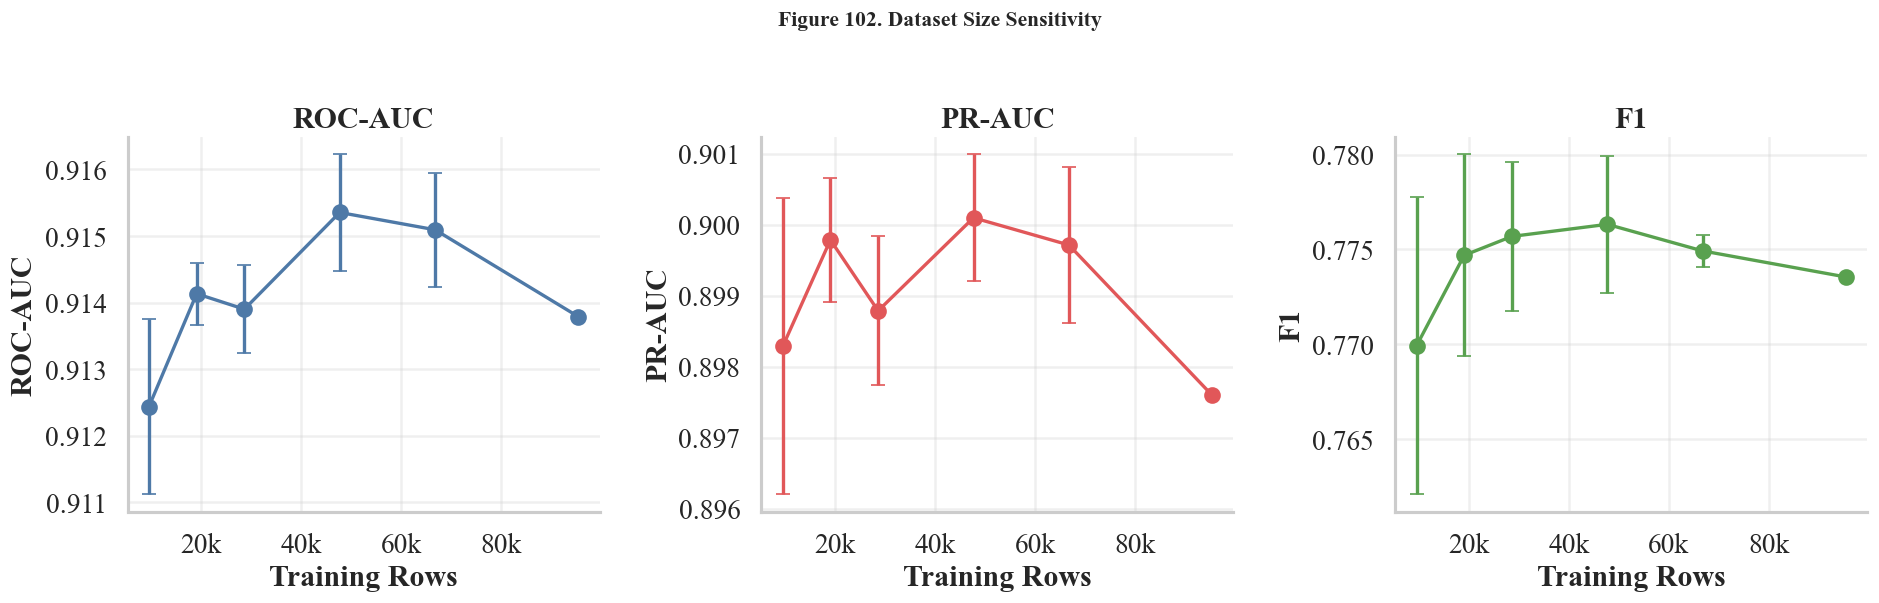

In [5]:
plot_dataset_size_sensitivity(size_df, FIG_DIR, fig_no=102)

**How to read this chart:**
- Each panel shows one metric (ROC-AUC, PR-AUC, F1) as training data increases
- Error bars show variance across 3 random subsamples at each size
- The x-axis shows actual row counts (not percentages)

**Key Takeaway**: Look for the "elbow" — the point where adding more data stops helping. If performance plateaus at 50k rows, then a hotel with 50k bookings can expect similar model quality to one with 100k. If it's still climbing at 100%, more data would likely help.

---
## 10.3 Threshold Policy Trade-offs — What does each policy sacrifice?

We offer three threshold policies, each optimizing for a different business goal:

| Policy | Goal | Typical use case |
|--------|------|------------------|
| **Max F1** | Best balance of precision and recall | General-purpose daily operations |
| **High Precision** | Almost no false alarms (precision ~100%) | Automated actions (auto-charging deposits) |
| **Cost Sensitive** | Minimize total EUR cost | Revenue management teams |

**Question**: What does each policy gain and lose compared to the others?

In [6]:
# Compare the three policies on the test set
policy_df = threshold_policy_comparison(ctx)

policy_df.style.format({
    "Threshold": "{:.2f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "Balanced Accuracy": "{:.4f}",
}).set_caption("Table 10.3 — Threshold policy comparison on test set")

,Policy,Threshold,Precision,Recall,F1,Balanced Accuracy
0,max_f1,0.41,0.6246,0.8946,0.7356,0.7839
1,high_precision,0.98,1.0000,0.0945,0.1727,0.5473
2,cost_sensitive,0.06,0.5184,0.9913,0.6808,0.7159


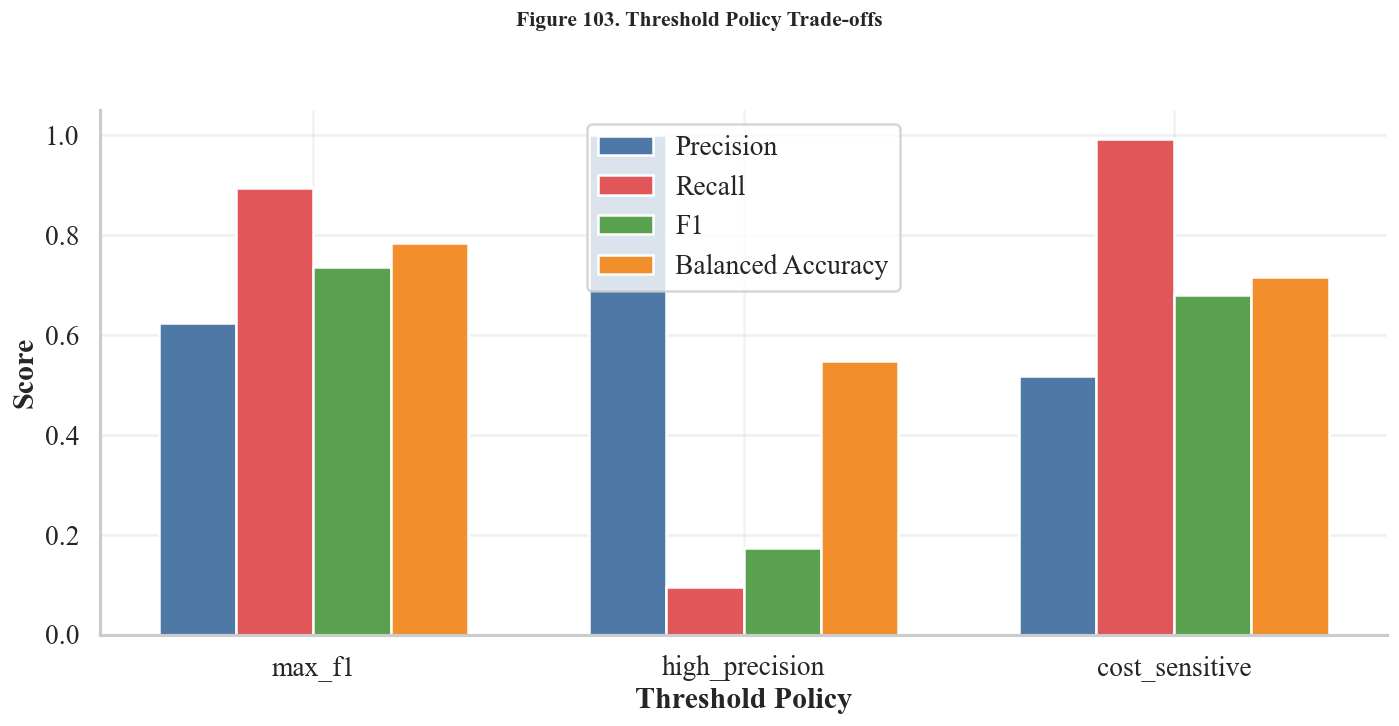

In [7]:
plot_threshold_policy_comparison(policy_df, FIG_DIR, fig_no=103)

**How to read this chart:**
- Each group of bars represents one threshold policy
- Taller bars = better performance on that metric
- The key trade-off is between precision (avoiding false alarms) and recall (catching real cancellations)

**Key Takeaway**: No single policy wins on all metrics — that's the point. Hotels must choose based on their operational priorities:
- Revenue teams should use **cost-sensitive** (catches nearly all cancellations, accepts some false alarms)
- Automated deposit systems should use **high-precision** (only acts when very confident)
- General reporting should use **max-F1** (balanced view)

---
## 10.4 Summary of Findings

| Question | Finding |
|----------|----------|
| **Cost sensitivity** | The optimal threshold is sensitive to FP cost assumptions. Hotels must estimate their actual intervention cost before deployment. |
| **Data hunger** | Performance is evaluated at 6 training set sizes. The plateau point indicates the minimum viable dataset for this prediction task. |
| **Policy trade-offs** | Each policy is optimal for its intended use case. There is no universally "best" threshold — the choice depends on business priorities. |

**Implication for deployment**: The model's threshold should be configurable per hotel, not hardcoded. The `config.py` constant `FP_INTERVENTION_COST` controls this — hotels should set it based on their actual cost of contacting a guest about a predicted cancellation.